In [2]:
pip install numpy pandas matplotlib scikit-learn tensorflow

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/375.7 MB 2.0 MB/s eta 0:03:11
   ---------------------------------------- 1.6/375.7 MB 2.7 MB/s eta 0:02:19
   ---------------------------------------- 2.6/375.7 MB 3.5 MB/s eta 0:01:47
   ---------------------------------------- 3.9/375.7 MB 4.1 MB/s eta 0:01:32
    --------------------------------------- 5.2/375.7 MB 4.5 MB/s eta 0:01:23
    --------------------------------------- 6.6/375.7 MB 4.8 MB/s eta 0:01:18
    --------------------------------------- 7.9/375.7 MB 5.0 MB/s eta 0:01:14
    --------------------------------------- 9.2/375.7 MB 5.0 MB/s eta 0:01:13
   - -------------------------------------- 10.2/375.7 MB 5.1 MB/s eta 0:01:12
   - --------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [4]:
train_data = pd.read_csv('train.csv')  # Update path
print("Shape of train_data:", train_data.shape)

X = train_data.iloc[:, 1:]  # Features (pixels)
y = train_data.iloc[:, 0]   # Labels (digits)
print("Shape of X:", X.shape)

Shape of train_data: (42000, 785)
Shape of X: (42000, 784)


In [5]:
X = X.values / 255.0  # Normalize pixel values (0-1)
X = X.reshape(-1, 28, 28, 1)  # Reshape for CNN (if needed)
y = to_categorical(y, num_classes=10)  # One-hot encode labels
print("Reshaped X:", X.shape)
print("One-hot y:", y.shape)

Reshaped X: (42000, 28, 28, 1)
One-hot y: (42000, 10)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)

Training data: (33600, 28, 28, 1)


In [7]:
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Input layer
    Dense(128, activation='relu'),     # Hidden layer 1
    Dense(64, activation='relu'),      # Hidden layer 2
    Dense(10, activation='softmax')    # Output layer (digits 0-9)
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8423 - loss: 0.5357 - val_accuracy: 0.9488 - val_loss: 0.1720
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9611 - loss: 0.1338 - val_accuracy: 0.9627 - val_loss: 0.1228
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9745 - loss: 0.0862 - val_accuracy: 0.9682 - val_loss: 0.1013
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9810 - loss: 0.0604 - val_accuracy: 0.9663 - val_loss: 0.1134
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9859 - loss: 0.0452 - val_accuracy: 0.9658 - val_loss: 0.1117
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0382 - val_accuracy: 0.9689 - val_loss: 0.1064
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9909 - loss: 0.0270 - val_accuracy: 0.9700 - val_loss: 0.1038
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9923 - loss: 0.0231 - 

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9716 - loss: 0.1238
Validation Accuracy: 97.11%


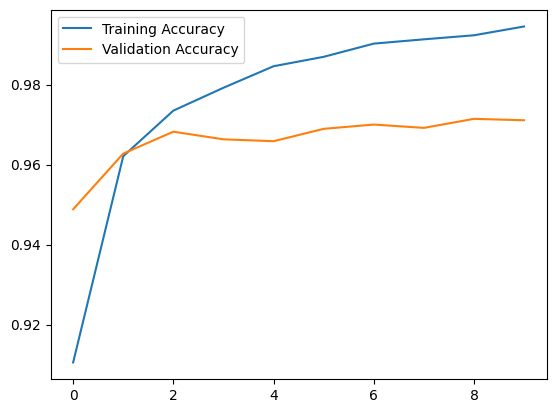

In [9]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [11]:
test_data = pd.read_csv('test.csv')
print("Data shape:", test_data.shape)
print("Total elements:", test_data.size)

# Show first row's length
print("Pixels in first image:", len(test_data.iloc[0]))

Data shape: (28000, 2)
Total elements: 56000
Pixels in first image: 2


In [14]:
test_data = pd.read_csv('test.csv')
print("CSV shape:", test_data.shape)  # Should be (N, 784)
print("First 5 columns:", test_data.columns[:5])

CSV shape: (28000, 2)
First 5 columns: Index(['ImageId', 'Label'], dtype='object')


In [17]:
print(test_data.shape)


(28000, 2)


In [20]:
print(test_data.columns)
print(test_data.head())


Index(['ImageId', 'Label'], dtype='object')
   ImageId  Label
0        1      0
1        2      0
2        3      0
3        4      0
4        5      0


In [23]:
!pip install kaggle

In [38]:
!kaggle competitions download -c digit-recognizer -f test.csv


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\HP\miniconda3\Scripts\kaggle.exe\__main__.py", line 4, in <module>
    from kaggle.cli import main
  File "C:\Users\HP\miniconda3\Lib\site-packages\kaggle\__init__.py", line 6, in <module>
    api.authenticate()
    ~~~~~~~~~~~~~~~~^^
  File "C:\Users\HP\miniconda3\Lib\site-packages\kaggle\api\kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
    ...<3 lines>...
                      self.config_file, self.config_dir))
OSError: Could not find kaggle.json. Make sure it's located in C:\Users\HP\.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


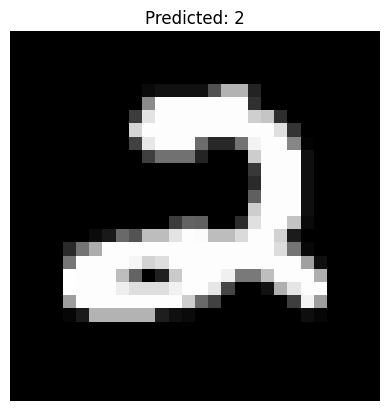

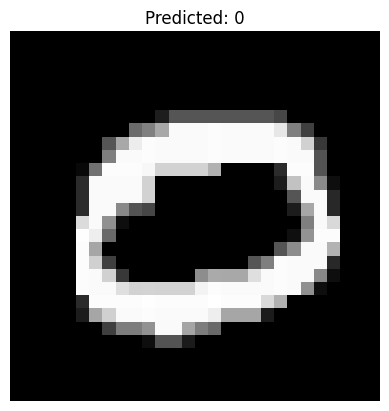

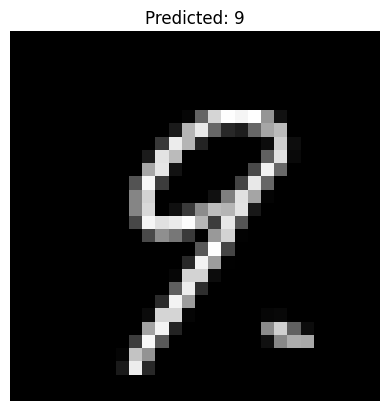

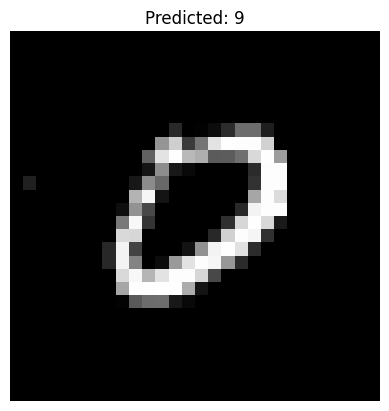

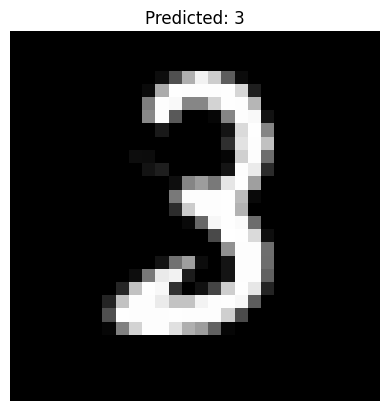

In [39]:
test_data = pd.read_csv('test.csv')
X_test = test_data.values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()